In [129]:
from pathlib import Path

import numpy as np
import scipy
import librosa

In [130]:
SR = 16_000

mfcc_global_means = np.array([-376.64493, 133.49261, 10.103006, 50.6346,
          2.5379617, -4.352536, -5.990294, -10.627845 ,
         -5.06056, -5.6066217, -6.399171, 1.2192086,
         -7.4254413, 1.972315 , -5.3393154, -1.6491263,
         -5.0894194, -1.6232326, -6.599448, -0.926722 ])

mfcc_global_stds =  np.array([71.68473, 51.73371, 35.530807, 38.962963, 28.962683, 20.55792,
       18.492373, 17.519913, 14.941453, 15.795096, 13.599268, 12.850418,
       12.626236, 12.163397, 11.049325, 10.311386, 9.885075, 9.155033,
        9.132711, 8.888399])

In [131]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")
plt.rcParams.update({
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.color": "gray",
    "grid.alpha": 0.6,
    "axes.labelcolor": "white",  
    "xtick.color": "white",     
    "ytick.color": "white"       
})

In [132]:
def hard_trim(audio, sr, start_sec=0.05, end_sec=0.05):
    start_sample = int(start_sec * sr)
    end_sample = int(end_sec * sr)
    
    return audio[start_sample:-end_sample]


def compute_snr(audio):
    energy = np.square(audio)
    signal_energy = np.mean(energy[energy > np.percentile(energy, 75)])
    noise_energy = np.mean(energy[energy < np.percentile(energy, 25)])
    
    return 10 * np.log10(signal_energy / (noise_energy + 1e-6))


def compute_speech_silence_ratio(audio, sr, top_db=10):
    non_silent_intervals = librosa.effects.split(audio, top_db=top_db)
    speech_duration = sum(end - start for start, end in non_silent_intervals) / sr
    total_duration = len(audio) / sr
    
    return speech_duration / total_duration


def compute_spectral_flatness(audio):
    flatness = librosa.feature.spectral_flatness(y=audio)
    
    return np.mean(flatness)


def estimate_top_db(audio):
    snr = compute_snr(audio)
    ssr = compute_speech_silence_ratio(audio, sr=16_000)
    s_flatness = compute_spectral_flatness(audio)
    
    # fitted regression line to find these coefficients
    top_db = -0.5596543 * snr + 0.36907558 * ssr -88.57209144 * s_flatness + 10 #29.032216978097267
    
    return np.clip(top_db, 5, 20)


def zero_pad_silence(audio):
    top_db = estimate_top_db(audio)
    
    non_silent_intervals = librosa.effects.split(audio, top_db=top_db)
   
    if n_intervals := len(non_silent_intervals) == 0:
        return audio
    elif n_intervals == 1:
        zeroed_audio = np.zeros_like(audio)
        start, end = non_silent_intervals[0]
        zeroed_audio[start:end] = audio[start:end]
        return zeroed_audio
    else:
        zeroed_audio = np.zeros_like(audio)
        start = non_silent_intervals[0][0] 
        end = non_silent_intervals[-1][1]
        zeroed_audio[start:end] = audio[start:end]
        
        return zeroed_audio
    
    
def normalize_amplitude(audio, target_db=-20):
    rms = np.sqrt(np.mean(audio**2))
    scalar = (10**(target_db / 20)) / (rms + 1e-6)
    
    return audio * scalar


def time_warp_resize(mel, target_frames=27):
    return scipy.ndimage.zoom(
        mel, (1, target_frames / mel.shape[1]), order=1
        )
    
    
def preprocess_audio(file_path):
    audio, _ = librosa.load(file_path, sr=SR)
    zero_audio = zero_pad_silence(audio)
    preprocessed_audio = np.trim_zeros(zero_audio)
    preprocessed_audio = normalize_amplitude(preprocessed_audio)

    return preprocessed_audio

In [133]:
def pipe_lms(file_path):
    """Pipeline for creating time-warped log mel-spectogram out of audio sample."""
    preprocessed_audio = preprocess_audio(file_path)
    mel_spec = librosa.feature.melspectrogram(y=preprocessed_audio, sr=SR, n_mels=80, hop_length=160, n_fft=400)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max) 
    log_mel_spec = (log_mel_spec - np.mean(log_mel_spec)) / np.std(log_mel_spec)
    warped_mel = time_warp_resize(log_mel_spec)
    
    return warped_mel


def pipe_mfcc(file_path, transpose = True):
    """Pipeline for creating time-warped mfcc out of audio sample."""
    preprocessed_audio = preprocess_audio(file_path)
    mfcc = librosa.feature.mfcc(y=preprocessed_audio, sr=SR, n_mfcc=20, n_fft=400, hop_length=160)
    
    warped_mfcc = time_warp_resize(mfcc) 
    normalized_mfcc = (warped_mfcc - mfcc_global_means[:, None]) / mfcc_global_stds[:, None]
   
    if transpose: return normalized_mfcc.T
    return normalized_mfcc

In [134]:
DATA_PATH = Path("../data/AudioMNIST")
audio_files = list(DATA_PATH.glob("*/*.wav"))

In [135]:
# used only for getting global values for pipe_mfcc
if False:
    from joblib import Parallel, delayed
    
    # using pipe_mfcc without normalization
    all_mfccs = Parallel(n_jobs=-1, backend='loky')(delayed(pipe_mfcc)(file) for file in audio_files)

    stacked = np.stack(all_mfccs)
    means = np.mean(stacked, axis=(0, 2))
    stds = np.std(stacked, axis=(0, 2))

In [136]:
random_file = np.random.choice(audio_files)

log_mel_spec = pipe_lms(random_file)
mfcc = pipe_mfcc(random_file)

In [137]:
%timeit pipe_lms(random_file)

10.3 ms ± 95.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [138]:
%timeit pipe_mfcc(random_file)

10.6 ms ± 420 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [139]:
log_mel_spec

array([[ 0.79075307,  0.8957743 ,  0.9239024 , ...,  0.9876206 ,
         0.94972646,  0.82112217],
       [ 0.47122896,  0.46316376,  0.48897442, ...,  1.2863685 ,
         1.0236067 ,  0.5903705 ],
       [ 0.04659217,  0.15503867,  0.44826615, ...,  1.5239316 ,
         1.3396441 ,  1.0571685 ],
       ...,
       [-1.0385745 , -1.1607693 , -1.2523214 , ..., -1.7032368 ,
        -1.3720866 , -0.95898384],
       [-1.2629981 , -1.2435452 , -1.2781594 , ..., -1.7323973 ,
        -1.3934013 , -0.9344257 ],
       [-1.0556628 , -1.4210871 , -1.7103319 , ..., -1.9717853 ,
        -1.5313996 , -0.9679723 ]], dtype=float32)

In [140]:
log_mel_spec.shape

(80, 27)

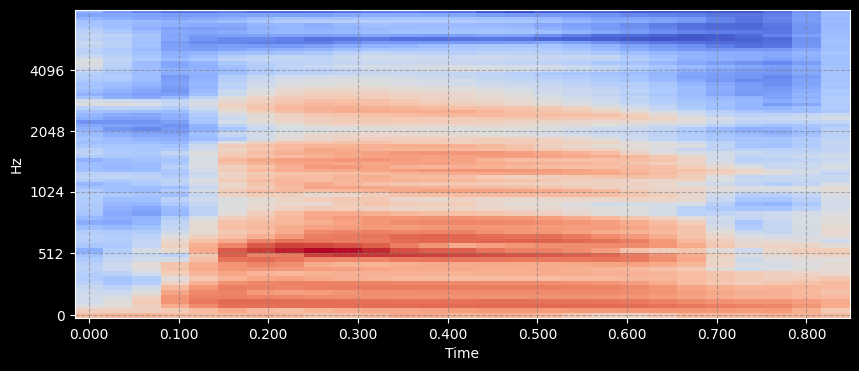

In [141]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(log_mel_spec, sr=SR, x_axis="time", y_axis="mel")

plt.show()

In [142]:
mfcc

array([[-9.63840972e-01, -2.40989988e+00,  5.98688385e-01,
        -7.76984616e-01, -8.25802316e-02,  1.97213012e+00,
         2.55454373e-01,  1.47800326e+00,  2.83598026e-01,
         1.10634327e+00,  5.07016588e-01,  5.05517404e-02,
         1.90575912e+00,  2.54986362e-01, -9.36487798e-01,
         1.79556475e+00,  6.90816828e-01, -5.76925282e-01,
         1.72852009e+00,  8.13875129e-01],
       [-1.21226142e+00, -2.13190192e+00,  6.57536618e-01,
        -6.91233345e-01,  1.30522978e-01,  1.85058502e+00,
         4.76409824e-02,  7.94416580e-01, -7.50644057e-02,
         1.57452230e+00,  9.26471160e-01,  8.75822894e-01,
         2.32490452e+00,  6.88994058e-01, -9.60319805e-01,
         1.40696474e+00,  1.08454938e+00, -8.03654570e-01,
         9.17255885e-01,  6.62669494e-01],
       [-1.27881711e+00, -1.55917793e+00,  7.32626150e-01,
        -6.18547349e-01,  3.06513920e-01,  1.52512233e+00,
        -6.09839932e-03,  3.09657776e-01, -2.27778101e-01,
         1.86306212e+00,  1.0

In [143]:
mfcc.shape

(27, 20)

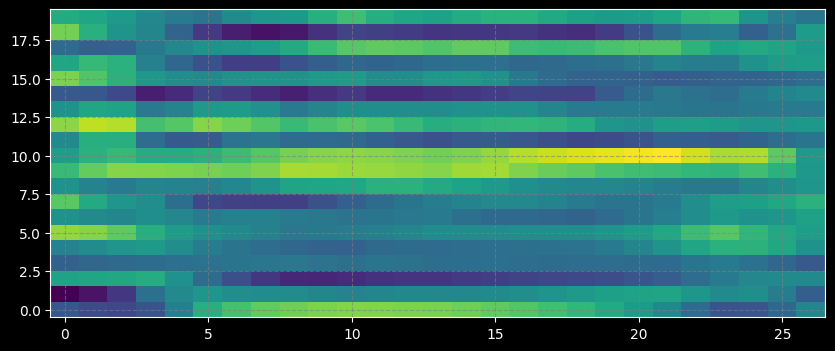

In [144]:
plt.figure(figsize=(10, 4))
plt.imshow(mfcc.T, aspect='auto', origin='lower', cmap='viridis')

plt.show()